In [54]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim

1. Generate Data

In [53]:
# Download stock data
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']

# Prepare training and testing data
x_test = yf.download(tickers, start="2023-01-01")['Close']
print("x_test shape:", x_test.shape)
ytest = x_test.pct_change().dropna()
print("y_test shape:", ytest.shape)

# Shouldn't train on future data, so we use data before 2023-01-01 for training
x_train = data[data.index < "2023-01-01"]
print("x_train shape:", x_train.shape)
y_train = x_train.pct_change().dropna()
print("y_train shape:", y_train.shape)

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

x_test shape: (801, 10)
y_test shape: (800, 10)
x_train shape: (1259, 10)
y_train shape: (1258, 10)


2. Graph Generation

In [43]:
def stock_graph(returns):
    # correlation matrix
    corr = returns.corr().values.copy()

    # remove self loops
    np.fill_diagonal(corr, 0)

    return corr

def normalize_graph(corr):
    eigenvalues, _ = np.linalg.eig(corr)

    return corr / np.max(eigenvalues)

3. Graph Filters

In [52]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

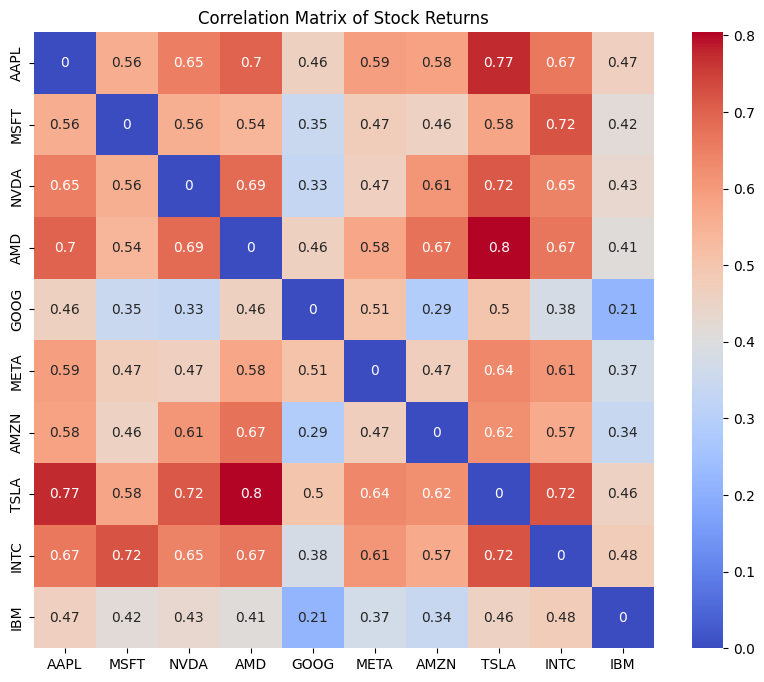

In [48]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_37200/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)


Epoch 10, Loss: 0.000495
Epoch 20, Loss: 0.000272
Epoch 30, Loss: 0.000130
Epoch 40, Loss: 0.000053
Epoch 50, Loss: 0.000020
Epoch 60, Loss: 0.000009
Epoch 70, Loss: 0.000006
Epoch 80, Loss: 0.000005
Epoch 90, Loss: 0.000004
Epoch 100, Loss: 0.000003


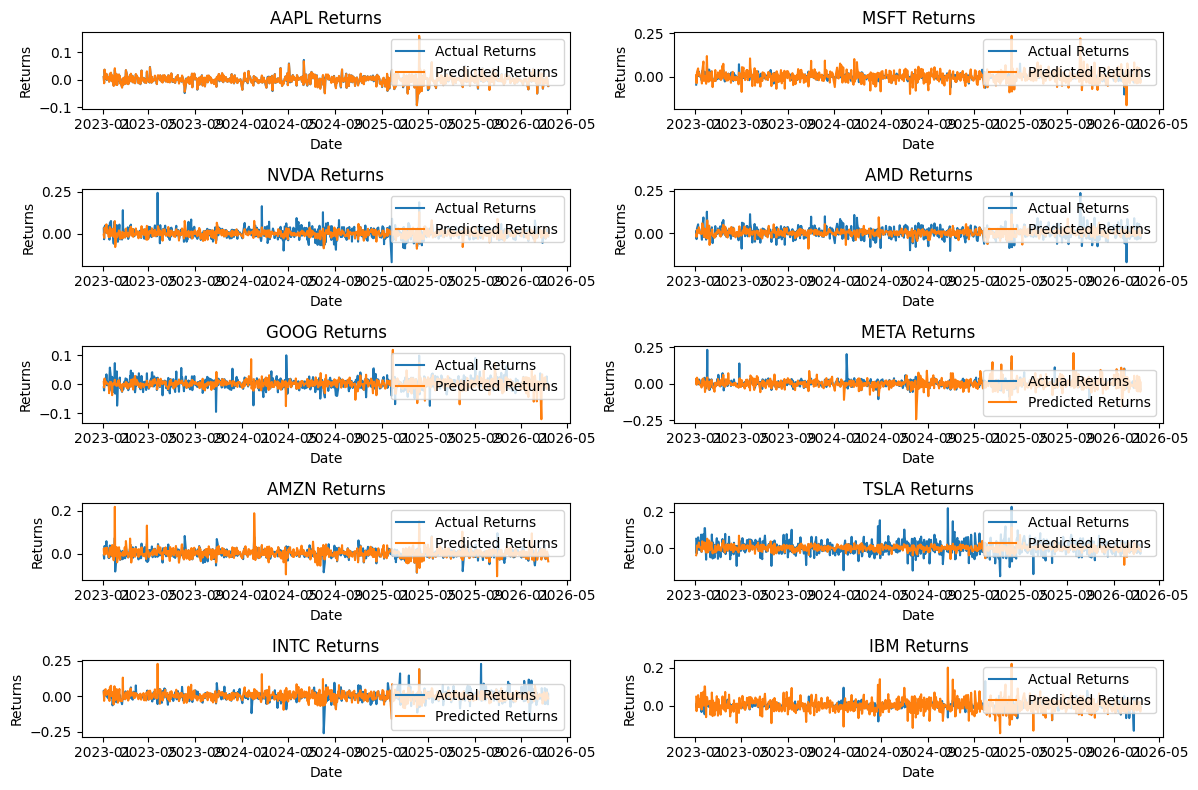

Validation Loss: 0.000004


In [59]:
# Plot test error
corr = stock_graph(y_train)       # correlation matrix
corr = normalize_graph(corr)      # optional normalization
corr = torch.tensor(corr, dtype=torch.float32)

k = 3  # number of filter taps
model = graph_filter(corr, k)

x_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_train_tensor = x_train_tensor.clone()  # example: predicting next-day returns

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 100

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = model(x_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    
    # Backprop
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

x_test_tensor = torch.tensor(ytest.values, dtype=torch.float32)
y_pred_test = model(x_test_tensor)

# Plot predicted vs actual returns per stock
plt.figure(figsize=(12, 8))
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(ytest.index, ytest[ticker], label='Actual Returns')
    plt.plot(ytest.index, y_pred_test[:, i].detach().numpy(), label='Predicted Returns')
    plt.title(f'{ticker} Returns')
    plt.xlabel('Date')
    plt.ylabel('Returns')
    plt.legend()
plt.tight_layout()
plt.show()

# Validation Loss
criterion = nn.MSELoss()
with torch.no_grad():
    val_loss = criterion(y_pred_test, x_test_tensor)
print(f"Validation Loss: {val_loss.item():.6f}")  



In [58]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y    